---
date: "2026-07-14"
date-modified: last-modified
format:
  html:
    toc: true
---

# Measurable Functions

## 1\. Motivation: The Limits of the Riemann Integral

The standard Riemann integral is constructed by partitioning the domain $[a, b]$ into subintervals and bounding the area under the curve using step functions. As the partition width $\Delta x_i$ approaches zero, we consider the limit of the Riemann sums $\sum f(x_i) (x_{i+1} - x_i)$.

While this approach succeeds for continuous and piecewise continuous functions, the Riemann integral has fundamental theoretical flaws:

1. **Existence:** There are bounded functions with erratic oscillations for which the Riemann integral simply does not exist.
2. **Convergence:** The pointwise or $L^1$ limit of a sequence of Riemann integrable functions is not necessarily Riemann integrable.

**Counterexample:** Consider the **Dirichlet function** on $[0, 1]$, defined as:
$$
f(x) = \begin{cases} 1 & \text{if } x \in \mathbb{Q} \\ 0 & \text{if } x \in \mathbb{Q}^c \end{cases}
$$
Because the rational numbers $\mathbb{Q}$ and irrationals $\mathbb{Q}^c$ are both [dense](density-theorem-of-R.ipynb) in $\mathbb{R}$, any subinterval in any partition of $[0, 1]$ contains both rational and irrational numbers. Thus, the upper Riemann sum is always $1$ and the lower Riemann sum is always $0$, meaning $f$ is not Riemann integrable.

To build a more robust theory of integration (the Lebesgue integral), we must generalize our approach by partitioning the *range* rather than the domain. For a target value $c$, we examine the set of domain points where the function takes values close to $c$, specifically preimages of the form $\{x \in X \mid f(x) \leq c\}$. For the integral over these sets to be well-defined, they must be assigned a valid measure—meaning they must belong to the underlying [$\sigma$-algebra](sigma-algebra.ipynb).

<!-- CELL BREAK -->

## 2\. Formal Definition and Equivalent Characterizations

Let $(X, \mathcal{M})$ be a [measurable space](measure.ipynb), where $X$ is a set and $\mathcal{M}$ is a [$\sigma$-algebra](sigma-algebra.ipynb) on $X$.

**Definition:** An extended real-valued function $f: X \to [-\infty, \infty]$ is said to be **measurable** (or $\mathcal{M}$-measurable) if for every real number $c \in \mathbb{R}$, the set $\{x \in X \mid f(x) \leq c\}$ is an element of the $\sigma$-algebra $\mathcal{M}$.

Because $\sigma$-algebras are closed under complements and countable unions/intersections, there are several equivalent ways to define measurability.

**Proposition 1 (Equivalent Definitions)**
Let $(X, \mathcal{M})$ be a measurable space and $f: X \to [-\infty, \infty]$ an extended real-valued function. The following statements are equivalent:

1. For each $c \in \mathbb{R}$, the set $\{x \in X \mid f(x) < c\}$ is measurable.
2. For each $c \in \mathbb{R}$, the set $\{x \in X \mid f(x) \leq c\}$ is measurable.
3. For each $c \in \mathbb{R}$, the set $\{x \in X \mid f(x) > c\}$ is measurable.
4. For each $c \in \mathbb{R}$, the set $\{x \in X \mid f(x) \geq c\}$ is measurable.

Furthermore, each of these conditions implies that for any extended real number $c \in [-\infty, \infty]$, the exact level set $\{x \in X \mid f(x) = c\}$ is measurable.

::: {.callout-tip collapse="true"}
## Proof of Proposition 1

**Step 1: $(1) \implies (2)$**
Assume $\{x \in X \mid f(x) < a\} \in \mathcal{M}$ for all $a \in \mathbb{R}$. For any fixed $c \in \mathbb{R}$, we can write the closed ray $(-\infty, c]$ as the countable intersection of open rays:
$$
(-\infty, c] = \bigcap_{k=1}^\infty \left(-\infty, c + \frac{1}{k}\right)
$$
Taking preimages under $f$, we obtain:
$$
\{x \in X \mid f(x) \leq c\} = \bigcap_{k=1}^\infty \left\{x \in X \mid f(x) < c + \frac{1}{k}\right\}
$$
Since each set in the countable intersection belongs to $\mathcal{M}$, and $\sigma$-algebras are closed under countable intersections, $\{x \in X \mid f(x) \leq c\} \in \mathcal{M}$.

**Step 2: $(2) \implies (3)$**
Assume $\{x \in X \mid f(x) \leq c\} \in \mathcal{M}$ for all $c \in \mathbb{R}$. Notice that $\{x \in X \mid f(x) > c\}$ is the complement of $\{x \in X \mid f(x) \leq c\}$ in $X$:
$$
\{x \in X \mid f(x) > c\} = X \setminus \{x \in X \mid f(x) \leq c\}
$$
Since $\sigma$-algebras are closed under complementation, $\{x \in X \mid f(x) > c\} \in \mathcal{M}$.

**Step 3: $(3) \implies (4)$**
Assume $\{x \in X \mid f(x) > a\} \in \mathcal{M}$ for all $a \in \mathbb{R}$. For any $c \in \mathbb{R}$, we express the closed ray $[c, \infty]$ as a countable intersection of open rays:
$$
\{x \in X \mid f(x) \geq c\} = \bigcap_{k=1}^\infty \left\{x \in X \mid f(x) > c - \frac{1}{k}\right\}
$$
Since each set in the intersection is in $\mathcal{M}$, their countable intersection is in $\mathcal{M}$, proving $\{x \in X \mid f(x) \geq c\} \in \mathcal{M}$.

**Step 4: $(4) \implies (1)$**
Assume $\{x \in X \mid f(x) \geq c\} \in \mathcal{M}$ for all $c \in \mathbb{R}$. Taking the complement in $X$:
$$
\{x \in X \mid f(x) < c\} = X \setminus \{x \in X \mid f(x) \geq c\}
$$
Thus $\{x \in X \mid f(x) < c\} \in \mathcal{M}$, establishing the equivalence of all four conditions.

**Step 5: Exact Level Sets are Measurable**
If $c \in \mathbb{R}$ is finite, we write:
$$
\{x \in X \mid f(x) = c\} = \{x \in X \mid f(x) \leq c\} \cap \{x \in X \mid f(x) \geq c\}
$$
As the intersection of two measurable sets, $\{x \in X \mid f(x) = c\} \in \mathcal{M}$.
For $c = \infty$, we write:
$$
\{x \in X \mid f(x) = \infty\} = \bigcap_{k=1}^\infty \{x \in X \mid f(x) > k\} \in \mathcal{M}
$$
And for $c = -\infty$:
$$
\{x \in X \mid f(x) = -\infty\} = \bigcap_{k=1}^\infty \{x \in X \mid f(x) < -k\} \in \mathcal{M}. \quad \blacksquare
$$
:::

::: {.callout-note}
## Intuition: Preimages of Rays
The condition $\{x \in X \mid f(x) \leq c\} \in \mathcal{M}$ can be written using preimage notation as $f^{-1}([-\infty, c]) \in \mathcal{M}$. This means that the function pulls back "nice" sets in $\mathbb{R}$ (specifically, left-infinite closed rays) into "nice" sets in the domain $X$ (elements of the $\sigma$-algebra). Because rays generate all Borel sets via countable unions and complements, controlling rays gives us control over all reasonable target sets.
:::


In [1]:
import warnings
warnings.filterwarnings('ignore')

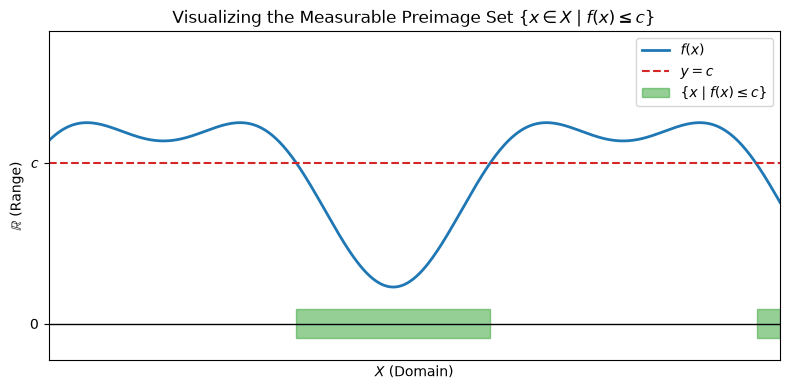

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Generate domain x values
x = np.linspace(0, 10, 500)
# Define a smooth mock function
y = np.sin(x) + 0.5 * np.cos(2 * x) + 2

c = 2.2  # Threshold c

plt.figure(figsize=(8, 4))
plt.plot(x, y, label=r'$f(x)$', color='#1f77b4', linewidth=2)
plt.axhline(y=c, color='#d62728', linestyle='--', label=r'$y = c$')

# Shade the region where f(x) <= c on the x-axis
mask = y <= c
plt.fill_between(x, -0.2, 0.2, where=mask, color='#2ca02c', alpha=0.5, label=r'$\{x \mid f(x) \leq c\}$')

# Add a black line to represent the x-axis clearly
plt.axhline(y=0, color='black', linewidth=1)

plt.xlim(0, 10)
plt.ylim(-0.5, 4)
plt.yticks([0, c], ['0', r'$c$'])
plt.xticks([])
plt.legend(loc='upper right')
plt.title(r'Visualizing the Measurable Preimage Set $\{x \in X \mid f(x) \leq c\}$')
plt.xlabel(r'$X$ (Domain)')
plt.ylabel(r'$\mathbb{R}$ (Range)')
plt.tight_layout()
plt.show()

<!-- CELL BREAK -->

## 3\. Topological Characterization of Measurability

While Proposition 1 uses rays (intervals of the form $(-\infty, c)$ or $[-\infty, c]$), we can extend this characterization to all open sets in $\mathbb{R}$.

**Proposition 2**
Let $(X, \mathcal{M})$ be a measurable space. A real-valued function $f: X \to \mathbb{R}$ is measurable if and only if for every [open set](metric-space-topology.ipynb) $O \subseteq \mathbb{R}$, the preimage $f^{-1}(O)$ is measurable (i.e., $f^{-1}(O) \in \mathcal{M}$).

::: {.callout-tip collapse="true"}
## Proof of Proposition 2

**Step 1: $(\impliedby)$**
Assume that for every open set $O \subseteq \mathbb{R}$, the preimage $f^{-1}(O) \in \mathcal{M}$.
For any real number $c \in \mathbb{R}$, the open ray $(-\infty, c)$ is an open set in $\mathbb{R}$.
By our assumption, $f^{-1}((-\infty, c)) = \{x \in X \mid f(x) < c\} \in \mathcal{M}$.
By Proposition 1 (condition 1), $f$ is a measurable function.

**Step 2: $(\implies)$**
Assume $f$ is a measurable function. Let $O \subseteq \mathbb{R}$ be an arbitrary open set.
By a fundamental theorem of topology on the real line, every open set $O \subseteq \mathbb{R}$ can be expressed as a countable union of pairwise disjoint open intervals:
$$
O = \bigcup_{k=1}^\infty (a_k, b_k)
$$
Because preimages preserve unions, we have:
$$
f^{-1}(O) = f^{-1}\left( \bigcup_{k=1}^\infty (a_k, b_k) \right) = \bigcup_{k=1}^\infty f^{-1}((a_k, b_k))
$$
Any open interval $(a_k, b_k)$ can be written as the intersection of two open rays:
$$
(a_k, b_k) = (-\infty, b_k) \cap (a_k, \infty)
$$
Therefore, $f^{-1}((a_k, b_k)) = \{x \in X \mid f(x) < b_k\} \cap \{x \in X \mid f(x) > a_k\}$.
Since $f$ is measurable, both sets in this intersection belong to $\mathcal{M}$ by Proposition 1. Since $\sigma$-algebras are closed under finite intersections, $f^{-1}((a_k, b_k)) \in \mathcal{M}$ for each $k$. Finally, because $\sigma$-algebras are closed under countable unions, the countable union $\bigcup_{k=1}^\infty f^{-1}((a_k, b_k)) = f^{-1}(O)$ belongs to $\mathcal{M}$. $\blacksquare$
:::

<!-- CELL BREAK -->

## 4\. Key Examples and Counterexamples

Here are several foundational examples illustrating how measurability depends on the underlying $\sigma$-algebra:

1. **Continuous Functions are Measurable:**
   Let $X = \mathbb{R}^n$ equipped with the [Borel $\sigma$-algebra](Borel-sets-and-measurability.ipynb) $\mathcal{B}(\mathbb{R}^n)$, and let $f: \mathbb{R}^n \to \mathbb{R}$ be a continuous function. For any open set $O \subseteq \mathbb{R}$, the definition of continuity in topology states that the preimage $f^{-1}(O)$ is an open set in $\mathbb{R}^n$. Since every open set in $\mathbb{R}^n$ is, by definition, a Borel set, $f^{-1}(O) \in \mathcal{B}(\mathbb{R}^n)$. Thus, by Proposition 2, every continuous function is Borel measurable (and consequently Lebesgue measurable).

2. **Indicator Functions ($\chi_E$):**
   For a subset $E \subseteq X$, the **indicator function** $\chi_E: X \to \mathbb{R}$ (also denoted $1_E$) is defined by:
   $$
   \chi_E(x) = \begin{cases} 1 & \text{if } x \in E \\ 0 & \text{if } x \notin E \end{cases}
   $$
   The preimage $\chi_E^{-1}((-\infty, c])$ depends on $c \in \mathbb{R}$:
   * If $c < 0$, $\chi_E^{-1}((-\infty, c]) = \varnothing$.
   * If $0 \leq c < 1$, $\chi_E^{-1}((-\infty, c]) = E^c$.
   * If $c \geq 1$, $\chi_E^{-1}((-\infty, c]) = X$.
   
   Since $\varnothing$ and $X$ are always in $\mathcal{M}$, $\chi_E$ is measurable if and only if $E^c \in \mathcal{M}$, which holds if and only if $E \in \mathcal{M}$. Thus, indicator functions directly mirror the measurability of the sets they indicate.

3. **The Dirichlet Function is Lebesgue Measurable:**
   The Dirichlet function $f(x) = \chi_{\mathbb{Q}}(x)$ on $\mathbb{R}$ is the indicator function of the rational numbers $\mathbb{Q}$. Since $\mathbb{Q}$ is a countable set, it has [Lebesgue outer measure](lebesgue-outer-measure.ipynb) zero ($m^*(\mathbb{Q}) = 0$), making both $\mathbb{Q}$ and the irrationals $\mathbb{Q}^c$ [Lebesgue measurable sets](measurable-sets.ipynb). Therefore, the Dirichlet function is Lebesgue measurable on $\mathbb{R}$, resolving the Riemann integral's breakdown.

4. **Power Set $\sigma$-algebra ($2^X$):**
   If the domain is equipped with the discrete power set $\sigma$-algebra $\mathcal{M} = 2^X$, then *every* function $f: X \to \mathbb{R}$ is automatically measurable, because all subsets of $X$ belong to $\mathcal{M}$.

5. **Trivial $\sigma$-algebra ($\{\varnothing, X\}$):**
   If $\mathcal{M} = \{\varnothing, X\}$, then only **constant functions** are measurable.
   *Proof:* For any real number $c$, the preimage $f^{-1}((-\infty, c])$ must equal either $\varnothing$ or $X$. If $f$ were not constant, taking $c$ between two distinct values in the range of $f$ would yield a non-empty, proper subset of $X$, contradicting $\mathcal{M} = \{\varnothing, X\}$.

<!-- CELL BREAK -->

## 5\. Operations on Measurable Functions

Measurable functions form a remarkably stable class under standard algebraic and lattice operations. Unlike Riemann integrability, measurability is preserved under addition, multiplication, and limits.

**Theorem 3 (Sums and Products of Measurable Functions)**
Let $(X, \mathcal{M})$ be a measurable space, and let $f$ and $g$ be measurable functions on $X$ that are finite [almost everywhere](Lebesgue-measure.ipynb) on $X$. Then:

1. **Linear Combinations:** For any real numbers $\alpha$ and $\beta$, the linear combination $\alpha f + \beta g$ is measurable on $X$.
2. **Products:** The product $f g$ is measurable on $X$.
3. **Squares and Powers:** If $f$ is measurable, then $f^2$ (and $f^k$ for any positive integer $k$) is measurable on $X$.

::: {.callout-tip collapse="true"}
## Proof of Theorem 3 (Sums, Squares, and Products)

Since $f$ and $g$ are finite almost everywhere, we may assume without loss of generality that $f$ and $g$ are finite on all of $X$ (as modifying functions on a set of measure zero preserves measurability when working with complete measures).

**Step 1: Scalar Multiplication ($\alpha f$)**
If $\alpha = 0$, then $\alpha f$ is the constant function $0$, which is measurable.
If $\alpha \neq 0$, observe that for any real number $c \in \mathbb{R}$:
$$
\{x \in X \mid \alpha f(x) > c\} = \{x \in X \mid f(x) > c/\alpha\} \quad \text{if } \alpha > 0
$$
and
$$
\{x \in X \mid \alpha f(x) > c\} = \{x \in X \mid f(x) < c/\alpha\} \quad \text{if } \alpha < 0.
$$
In both cases, the set on the right-hand side belongs to $\mathcal{M}$ because $f$ is measurable (using Proposition 1). Thus, $\alpha f$ is measurable. Consequently, to establish linearity for $\alpha f + \beta g$, it suffices to prove that the sum $f + g$ is measurable when $\alpha = \beta = 1$.

**Step 2: Sums ($f + g$)**
For any $x \in X$, if $f(x) + g(x) < c$, then rearranging the inequality yields $f(x) < c - g(x)$. By the density of rational numbers$\mathbb{Q}$ in $\mathbb{R}$, between any two distinct real numbers there exists a rational number. Therefore, there is a rational number $q \in \mathbb{Q}$ such that:
$$
f(x) < q < c - g(x)
$$
Notice that the inequality $q < c - g(x)$ is equivalent to $g(x) < c - q$. Hence, an element $x \in X$ satisfies $f(x) + g(x) < c$ if and only if there exists some rational $q \in \mathbb{Q}$ such that both $f(x) < q$ and $g(x) < c - q$ hold simultaneously. We can express the level set as:
$$
\{x \in X \mid f(x) + g(x) < c\} = \bigcup_{q \in \mathbb{Q}} \Big( \{x \in X \mid g(x) < c - q\} \cap \{x \in X \mid f(x) < q\} \Big)
$$
Since $f$ and $g$ are measurable, the sets $\{x \in X \mid g(x) < c - q\}$ and $\{x \in X \mid f(x) < q\}$ belong to $\mathcal{M}$ for every rational $q \in \mathbb{Q}$. Because $\mathcal{M}$ is closed under finite intersections, each intersection inside the union is in $\mathcal{M}$. Furthermore, because the set of rational numbers $\mathbb{Q}$ is countable, the union over $q \in \mathbb{Q}$ is a countable union of measurable sets. Since $\sigma$-algebras are closed under countable unions, $\{x \in X \mid f(x) + g(x) < c\} \in \mathcal{M}$. By Proposition 1, $f + g$ is measurable.

**Step 3: Squares ($f^2$)**
To prove that the product of two measurable functions is measurable, we first show that the square of a measurable function is measurable. For any threshold $c \geq 0$:
$$
\{x \in X \mid f^2(x) > c\} = \{x \in X \mid f(x) > \sqrt{c}\} \cup \{x \in X \mid f(x) < -\sqrt{c}\}
$$
Since $f$ is measurable, both sets on the right belong to $\mathcal{M}$, so their union is in $\mathcal{M}$.
If $c < 0$, then $f^2(x) \geq 0 > c$ for all $x \in X$, meaning:
$$
\{x \in X \mid f^2(x) > c\} = X \in \mathcal{M}
$$
Thus, $f^2$ is measurable.

**Step 4: Products ($fg$)**
We now apply the algebraic polarization identity:
$$
fg = \frac{1}{2} \left[ (f+g)^2 - f^2 - g^2 \right]
$$
By Step 2, $f+g$ is measurable. By Step 3, the squares $(f+g)^2$, $f^2$, and $g^2$ are all measurable. By Steps 1 and 2, any linear combination of measurable functions is measurable. Therefore, $fg$ is measurable. $\blacksquare$
:::


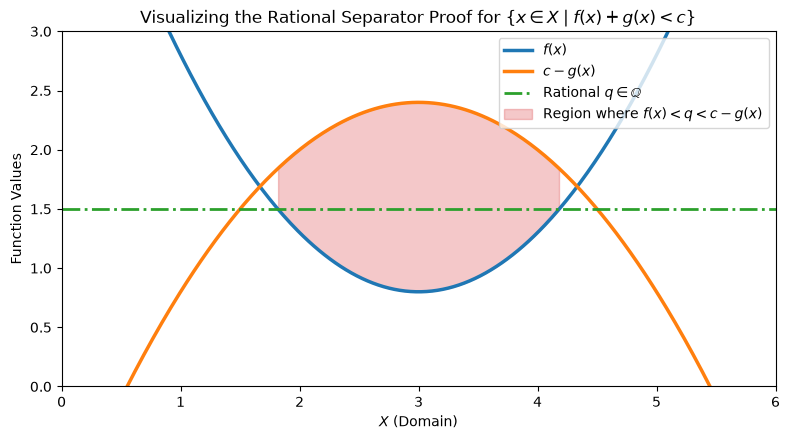

In [3]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(0, 6, 400)
# Define curves where f(x) + g(x) < c on a central interval
f_x = 0.5 * (x - 3)**2 + 0.8
c_minus_g_x = -0.4 * (x - 3)**2 + 2.4

q = 1.5  # A rational number separating f(x) and c - g(x)

plt.figure(figsize=(8, 4.5))
plt.plot(x, f_x, label=r'$f(x)$', color='#1f77b4', linewidth=2.5)
plt.plot(x, c_minus_g_x, label=r'$c - g(x)$', color='#ff7f0e', linewidth=2.5)
plt.axhline(y=q, color='#2ca02c', linestyle='-.', linewidth=2, label=r'Rational $q \in \mathbb{Q}$')

# Shade the region where f(x) < q < c - g(x)
mask = (f_x < q) & (q < c_minus_g_x)
plt.fill_between(x, f_x, c_minus_g_x, where=mask, color='#d62728', alpha=0.25, label=r'Region where $f(x) < q < c - g(x)$')

plt.xlim(0, 6)
plt.ylim(0, 3)
plt.title(r'Visualizing the Rational Separator Proof for $\{x \in X \mid f(x) + g(x) < c\}$')
plt.xlabel(r'$X$ (Domain)')
plt.ylabel(r'Function Values')
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

In addition to algebraic combinations, measurable functions are closed under lattice operations:

**Proposition 4 (Lattice Operations)**
Let $(X, \mathcal{M})$ be a measurable space, and let $f$ and $g$ be measurable functions on $X$. Then:

1. **Maximum and Minimum:** The functions $\max\{f, g\}$ and $\min\{f, g\}$ are measurable.
2. **Positive and Negative Parts:** The positive part $f^+ = \max\{f, 0\}$ and negative part $f^- = \max\{-f, 0\}$ are measurable.
3. **Absolute Value:** The absolute value $|f| = f^+ + f^-$ is measurable.

::: {.callout-tip collapse="true"}
## Proof of Proposition 4

**Step 1: Maximum ($\max\{f, g\}$)**
For any real number $c \in \mathbb{R}$, observe that $\max\{f(x), g(x)\} > c$ if and only if either $f(x) > c$ or $g(x) > c$. Therefore:
$$
\{x \in X \mid \max\{f(x), g(x)\} > c\} = \{x \in X \mid f(x) > c\} \cup \{x \in X \mid g(x) > c\}
$$
Since $f$ and $g$ are measurable, both sets on the right are in $\mathcal{M}$, so their union is in $\mathcal{M}$. By Proposition 1, $\max\{f, g\}$ is measurable.

**Step 2: Minimum ($\min\{f, g\}$)**
Similarly, $\min\{f(x), g(x)\} > c$ if and only if both $f(x) > c$ and $g(x) > c$ hold simultaneously:
$$
\{x \in X \mid \min\{f(x), g(x)\} > c\} = \{x \in X \mid f(x) > c\} \cap \{x \in X \mid g(x) > c\}
$$
As the intersection of two measurable sets, this belongs to $\mathcal{M}$. Thus, $\min\{f, g\}$ is measurable.

**Step 3: Positive and Negative Parts and Absolute Value**
Since the constant function $0$ is measurable, $f^+ = \max\{f, 0\}$ and $f^- = \max\{-f, 0\}$ are measurable by Step 1.
Finally, the absolute value is given by $|f| = f^+ + f^-$. Since $f^+$ and $f^-$ are measurable, their sum $|f|$ is measurable by Theorem 3.
Alternatively, one can check preimages directly: for $c \geq 0$, $\{x \in X \mid |f(x)| > c\} = \{x \in X \mid f(x) > c\} \cup \{x \in X \mid f(x) < -c\} \in \mathcal{M}$. $\blacksquare$
:::

::: {.callout-warning}
## The Converse of Absolute Value Measurability is False
If $|f|$ is measurable, it is **not** necessarily true that $f$ is measurable.
For example, let $V \subset \mathbb{R}$ be a non-measurable set (such as a Vitali set), and define $f: \mathbb{R} \to \mathbb{R}$ by:
$$
f(x) = \begin{cases} 1 & \text{if } x \in V \\ -1 & \text{if } x \notin V \end{cases}
$$
The absolute value $|f(x)| = 1$ everywhere, which is a constant function and hence measurable. However, $f^{-1}(\{1\}) = V$, which is not Lebesgue measurable. Therefore, $f$ is not measurable.
:::

<!-- CELL BREAK -->

## 6\. Compositions of Measurable Functions

**Proposition 5 (Composition with Continuous Functions)**
Let $(X, \mathcal{M})$ be a measurable space, let $f: X \to \mathbb{R}$ be a measurable function, and let $\varphi: \mathbb{R} \to \mathbb{R}$ be a [continuous function](continuity-topology.ipynb). Then the composition $\varphi \circ f: X \to \mathbb{R}$ is measurable.

::: {.callout-tip collapse="true"}
## Proof of Proposition 5

Let $O \subseteq \mathbb{R}$ be an arbitrary open set.
Because $\varphi: \mathbb{R} \to \mathbb{R}$ is continuous, the preimage of any open set under $\varphi$ is open in $\mathbb{R}$. Thus, $\varphi^{-1}(O)$ is an open set in $\mathbb{R}$.

Since $\varphi^{-1}(O)$ is open and $f$ is a measurable function, we can apply Proposition 2, which states that the preimage of any open set under a measurable function is measurable. Therefore:
$$
f^{-1}(\varphi^{-1}(O)) \in \mathcal{M}
$$
By the associative definition of preimages and composition:
$$
f^{-1}(\varphi^{-1}(O)) = (\varphi \circ f)^{-1}(O)
$$
Because the preimage $(\varphi \circ f)^{-1}(O)$ belongs to $\mathcal{M}$ for every open set $O \subseteq \mathbb{R}$, the composition $\varphi \circ f$ is measurable by Proposition 2. $\blacksquare$
:::

::: {.callout-warning}
## Composition of Two Measurable Functions Need Not Be Measurable
While composing a continuous function $\varphi$ with a measurable function $f$ ($\varphi \circ f$) is always measurable, composing two Lebesgue measurable functions ($g \circ f$, where both $f$ and $g$ are Lebesgue measurable) is **not** necessarily Lebesgue measurable in general. This occurs because the preimage of a Lebesgue measurable set under a continuous or measurable function is not guaranteed to be Lebesgue measurable without additional Borel conditions.
:::